# 산학프로젝트
**제조 공정 품질 불량 예측**

# 04_5_AutoEncoder+GridSearch

- 입력 데이터: 02_EDA가 저장한 `labeled_modeling.csv`
- 오토인코더 복원 오차 특성 추가 판단 (후보 검증)
- 평가 프로토콜: 80/20 단일 분할 + GridSearch. 오토인코더를 **fold 밖에서 1회 학습**했으므로 낙관 편향이 있음
- 주의: 최종 판단은 **04_6에서 fold 안 재학습**으로 내렸고, 결론은 **최종 모델 미적용**임

## import

In [1]:
import pandas as pd
import numpy as np
import os

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [3]:
# 02_EDA에서 저장한 전처리 데이터
# - 기록 오류 보정, 중복 제거, CN7·RG3 한정, PassOrFail 인코딩(양품 0 / 불량 1), Part 파생까지 끝난 상태
model_data=pd.read_csv('labeled_modeling.csv', index_col=0)

print(f'{model_data.shape[0]}행 {model_data.shape[1]}컬럼 / 불량 {int(model_data["PassOrFail"].sum())}건')

result_df=pd.read_csv('04_1_Imbalance_and_Feature_Experiments.csv')

5230행 30컬럼 / 불량 60건


In [4]:
# Grid Search 관련 라이브러리
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn import set_config
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 오토인코더 관련 라이브러리
import keras
from keras import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.model_evaluation import evaluate_models
import utils.model_tuning as model_tuning

# 노트북 실행 중 model_tuning.py를 수정한 경우에도 최신 코드를 다시 불러옴
importlib.invalidate_caches()
model_tuning = importlib.reload(model_tuning)

grid_search_bagging_smote = model_tuning.grid_search_bagging_smote
grid_search_random_forest_balanced = model_tuning.grid_search_random_forest_balanced
grid_search_random_forest_smote = model_tuning.grid_search_random_forest_smote

set_config(display='text')

# 그래프 한글 표시
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

## 데이터 전처리

In [5]:
# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

final_df=model_data.drop(columns=drop_columns)

X_part=final_df.drop(columns='PassOrFail')
Y=final_df['PassOrFail']

# 더미변수 생성
X_part = pd.get_dummies(data = X_part, columns = ['Part'], drop_first=True, dtype=int)

In [6]:
# 04_2와 동일한 train/test 분할
x_part_train, x_part_test, y_train, y_test = train_test_split(
    X_part,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=0,
)

print(f'X_Train: {x_part_train.shape}, X_Test: {x_part_test.shape}')
print(f'불량 수 - Train: {y_train.sum()}, Test: {y_test.sum()}')

X_Train: (4184, 26), X_Test: (1046, 26)
불량 수 - Train: 48, Test: 12


## 오토인코더 Reconstruction Error

### 오토인코더 구성

- 학습 데이터의 **양품만** MinMaxScaler로 0~1 정규화 후 학습 (`Part` 더미변수 포함)
- 대칭 구조 `26 → 은닉층 → 병목 → 은닉층 → 26`, 은닉층 relu / 출력층 sigmoid
- 손실 MSE, Adam(0.001), batch_size=64, 최대 400 epochs, EarlyStopping(patience=30)
- 복원 오차는 시드 3개 평균으로 계산 (초기 가중치에 따라 복원 오차가 흔들려 시드 1개로는 재현되지 않음)

In [7]:
# 양품만 사용
x_normal=x_part_train[y_train==0]

ae_scaler=MinMaxScaler()
x_normal_scaled=ae_scaler.fit_transform(x_normal)

print(f'오토인코더 학습 데이터(양품): {x_normal_scaled.shape}')


def build_ae(hidden_units, latent_units, n_features, seed=0):
    keras.utils.set_random_seed(seed)

    encoder=Sequential([Dense(units, activation='relu') for units in hidden_units]
                       +[Dense(latent_units, activation='relu')], name='encoder')
    decoder=Sequential([Dense(units, activation='relu') for units in reversed(hidden_units)]
                       +[Dense(n_features, activation='sigmoid')], name='decoder')

    ae=Sequential([Input(shape=(n_features,)), encoder, decoder], name='autoencoder')
    ae.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
    return ae


def fit_ae(ae, x):
    return ae.fit(x, x, batch_size=64, epochs=400, validation_split=0.2, verbose=0,
                  callbacks=[EarlyStopping(monitor='val_loss', patience=30, mode='min', restore_best_weights=True)])

오토인코더 학습 데이터(양품): (4136, 26)


### 구조 탐색

- 라벨을 쓰지 않고 양품 검증 복원 손실(val_loss)만으로 선택
- 병목이 너무 좁으면 양품도 복원하지 못하고, 너무 넓으면 불량까지 복원해 신호가 약해짐
- 초기 가중치에 따라 복원 오차가 크게 흔들리므로 후보마다 시드 3개를 학습해 평균 val_loss로 비교

In [8]:
ae_seeds=[0, 1, 2]
ae_space=[([16], 8), ([16], 12), ([20], 12), ([24, 12], 8)]

ae_candidates={}
search_rows=[]

for hidden_units, latent_units in ae_space:
    key=(tuple(hidden_units), latent_units)
    ae_candidates[key]=[]
    val_losses=[]

    for seed in ae_seeds:
        ae=build_ae(hidden_units, latent_units, x_normal_scaled.shape[1], seed=seed)
        history=fit_ae(ae, x_normal_scaled)
        ae_candidates[key].append((ae, history))
        val_losses.append(min(history.history['val_loss']))

    search_rows.append({
        'Hidden Units': str(hidden_units),
        'Latent Units': latent_units,
        'Val Loss Mean': np.mean(val_losses),
        'Val Loss Std': np.std(val_losses),
        'Key': key,
    })
    print(f'hidden={hidden_units}, latent={latent_units} 완료')

ae_search_df=pd.DataFrame(search_rows).sort_values('Val Loss Mean', ignore_index=True)
ae_search_df.drop(columns='Key')

hidden=[16], latent=8 완료


hidden=[16], latent=12 완료


hidden=[20], latent=12 완료


hidden=[24, 12], latent=8 완료


,Hidden Units,Latent Units,Val Loss Mean,Val Loss Std
0,[20],12,0.000148,0.000003
1,[16],12,0.000180,0.000035
2,"[24, 12]",8,0.000181,0.000007
3,[16],8,0.000192,0.000037


In [9]:
# 최저 평균 val_loss의 1.2배 이내에서 병목이 가장 작은 구조 선택
tolerance=ae_search_df['Val Loss Mean'].min()*1.2
best_ae=ae_search_df[ae_search_df['Val Loss Mean']<=tolerance].sort_values(['Latent Units', 'Val Loss Mean'], ignore_index=True).iloc[0]

ae_list=[ae for ae, _ in ae_candidates[best_ae['Key']]]
history_list=[history for _, history in ae_candidates[best_ae['Key']]]

print(f"선택 구조: hidden={best_ae['Hidden Units']}, latent={best_ae['Latent Units']}")
print(f"Val Loss Mean: {best_ae['Val Loss Mean']:.6f} (Std: {best_ae['Val Loss Std']:.6f})")
ae_list[0].summary()

선택 구조: hidden=[20], latent=12
Val Loss Mean: 0.000148 (Std: 0.000003)


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 12)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 26)             │           806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,796 (18.74 KB)

 Trainable params: 1,598 (6.24 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,198 (12.50 KB)

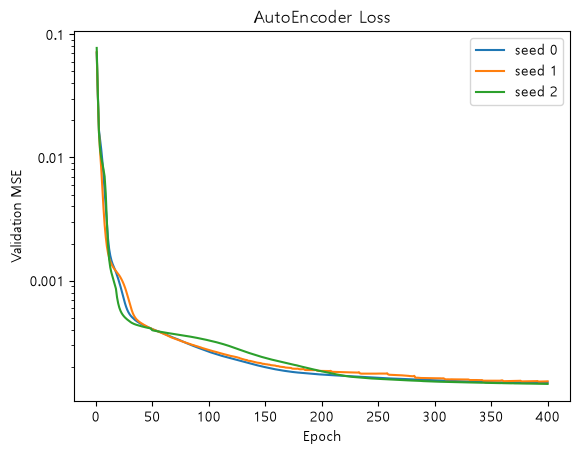

In [10]:
for seed, history in zip(ae_seeds, history_list):
    loss_df=pd.DataFrame(history.history)
    plt.plot(loss_df.index+1, loss_df['val_loss'], label=f'seed {seed}')

plt.yscale('log')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value:g}'))
plt.gca().yaxis.set_minor_formatter(NullFormatter())
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.title('AutoEncoder Loss')
plt.legend()
plt.show()

### Reconstruction Error 계산

- 시드 3개의 복원 오차를 평균해서 사용

In [11]:
def recon_error(x):
    scaled=ae_scaler.transform(x)
    errors=[np.mean(np.square(ae.predict(scaled, verbose=0)-scaled), axis=1) for ae in ae_list]
    return np.mean(errors, axis=0)


recon_train=recon_error(x_part_train)
recon_test=recon_error(x_part_test)

# 원본 특성에 복원 오차 추가
x_ae_train=x_part_train.assign(Recon_Error=recon_train)
x_ae_test=x_part_test.assign(Recon_Error=recon_test)

print(f'특성 수: {x_part_train.shape[1]} -> {x_ae_train.shape[1]}')

pd.DataFrame({'Recon_Error': recon_test, 'PassOrFail': y_test.values}).groupby('PassOrFail')['Recon_Error'].agg(['count', 'mean', 'median', 'max'])

특성 수: 26 -> 27


,count,mean,median,max
PassOrFail,,,,
0,1034,0.000124,0.000097,0.001611
1,12,0.005666,0.000499,0.030110


### 복원 오차 단독 성능

- 임계값은 학습 데이터 양품의 평균 ± 시그마 기준이며, Grid Search에는 사용하지 않음

In [12]:
print(f'복원 오차 단독 Average Precision: {average_precision_score(y_test, recon_test):.4f}')
print(f'평가 데이터 불량 비율: {y_test.mean():.4f}')

error_mean=recon_train[y_train.values==0].mean()
error_std=recon_train[y_train.values==0].std()

sigma_rows=[]
for sigma in [3, 5]:
    threshold=error_mean+sigma*error_std
    pred=(recon_test>threshold).astype(int)
    tn, fp, fn, tp=confusion_matrix(y_test, pred, labels=[0, 1]).ravel()

    sigma_rows.append({
        'Rule': f'{sigma} sigma',
        'Threshold': threshold,
        'Defect Precision': precision_score(y_test, pred, zero_division=0),
        'Defect Recall': recall_score(y_test, pred, zero_division=0),
        'Defect F1 Score': f1_score(y_test, pred, zero_division=0),
        '불량 탐지 수': f'{tp}/{tp + fn}',
        '양품 오탐 수': f'{fp}/{fp + tn}',
    })

pd.DataFrame(sigma_rows)

복원 오차 단독 Average Precision: 0.4799
평가 데이터 불량 비율: 0.0115


,Rule,Threshold,Defect Precision,Defect Recall,Defect F1 Score,불량 탐지 수,양품 오탐 수
0,3 sigma,0.001746,1.0,0.333333,0.5,4/12,0/1034
1,5 sigma,0.002818,1.0,0.333333,0.5,4/12,0/1034


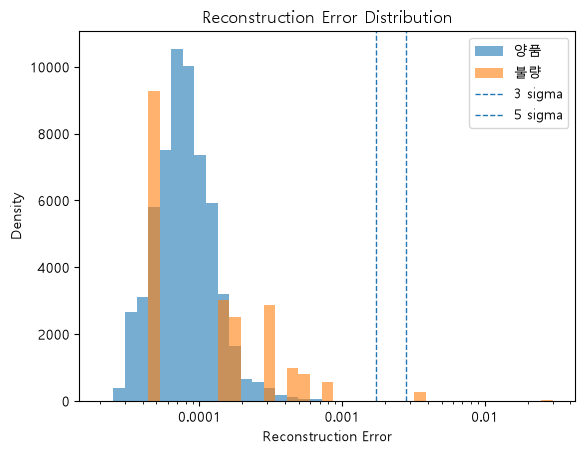

In [13]:
# 복원 오차가 0 근처에 몰려 있어 로그 구간으로 나눠서 확인
bins=np.logspace(np.log10(recon_test.min()), np.log10(recon_test.max()), 40)

plt.hist(recon_test[y_test.values==0], bins=bins, density=True, alpha=0.6, label='양품')
plt.hist(recon_test[y_test.values==1], bins=bins, density=True, alpha=0.6, label='불량')
for sigma in [3, 5]:
    plt.axvline(error_mean+sigma*error_std, linestyle='--', linewidth=1, label=f'{sigma} sigma')
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value:g}'))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.title('Reconstruction Error Distribution')
plt.legend()
plt.show()

## 원본 특성 기준선

- 04_2 Grid Search가 선택한 파라미터를 원본 26개 특성으로 다시 학습
- SMOTE 계열 두 모델은 04_2 **보정 전** GridSearch 파라미터(RandomForest SMOTE `n_estimators=500, min_samples_leaf=4`, Bagging `n_estimators=300, max_samples=1.0`)를 사용. 보정 후 재탐색 값과 다르나 이 노트북의 판단(복원 오차 특성 추가 여부)에는 영향 없음

In [14]:
model_dict={}

# 1. RandomForest PART_NAME + Balanced
model_dict['RandomForest PART_NAME + Balanced (04_2)']=Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=2, min_samples_leaf=4,
                                  class_weight='balanced', n_jobs=1, random_state=0)),
])

# 2. RandomForest PART_NAME + SMOTE St=0.1
model_dict['RandomForest PART_NAME + SMOTE St=0.1 (04_2)']=Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)),
    ('rf', RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_split=2, min_samples_leaf=4,
                                  n_jobs=1, random_state=0)),
])

# 3. Bagging PART_NAME + SMOTE St=0.1
model_dict['Bagging PART_NAME + SMOTE St=0.1 (04_2)']=Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)),
    ('bagging', BaggingClassifier(n_estimators=300, max_samples=1.0, max_features=0.5, n_jobs=1, random_state=0)),
])

for name in model_dict:
    model_dict[name].fit(x_part_train, y_train)

RandomForest PART_NAME + Balanced (04_2)
Accuracy: 0.9780114722753346
Average Precision: 0.5694804809388142
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.98      0.99      1034
          불량       0.30      0.67      0.41        12

    accuracy                           0.98      1046
   macro avg       0.65      0.82      0.70      1046
weighted avg       0.99      0.98      0.98      1046

RandomForest PART_NAME + SMOTE St=0.1 (04_2)
Accuracy: 0.9933078393881453
Average Precision: 0.6440449594581789
Classification Report
              precision    recall  f1-score   support

          양품       1.00      1.00      1.00      1034
          불량       0.78      0.58      0.67        12

    accuracy                           0.99      1046
   macro avg       0.89      0.79      0.83      1046
weighted avg       0.99      0.99      0.99      1046



Bagging PART_NAME + SMOTE St=0.1 (04_2)
Accuracy: 0.9894837476099426
Average Precision: 0.6290204008198087
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.54      0.58      0.56        12

    accuracy                           0.99      1046
   macro avg       0.77      0.79      0.78      1046
weighted avg       0.99      0.99      0.99      1046



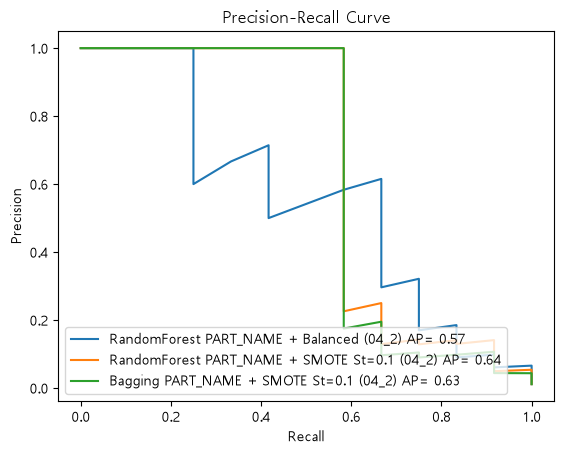

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
19,RandomForest PART_NAME + Balanced (04_2),0.296296,0.666667,0.410256,0.569480
20,RandomForest PART_NAME + SMOTE St=0.1 (04_2),0.777778,0.583333,0.666667,0.644045
21,Bagging PART_NAME + SMOTE St=0.1 (04_2),0.538462,0.583333,0.560000,0.629020


In [15]:
result_df = evaluate_models(model_dict, x_part_test, y_test, result_df)
result_df.tail(3)

## 1. RandomForest PART_NAME + Recon Error + Balanced Grid Search

- 입력은 원본 26개 특성 + Recon_Error
- SMOTE 미적용, RandomForest의 class_weight='balanced' 사용
- 평가 지표는 Average Precision, StandardScaler는 각 Stratified K-Fold의 학습 폴드 안에서만 적합
- 54개 조합 × 5 folds = 270 fits

In [16]:
rf_balanced_param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
}

rf_balanced_grid, rf_balanced_cv_results = grid_search_random_forest_balanced(
    x_ae_train,
    y_train,
    param_grid=rf_balanced_param_grid,
    n_splits=5,
    scoring='average_precision',
    random_state=0,
    n_jobs=-1,
    verbose=1,
)

print('Best CV Average Precision:', rf_balanced_grid.best_score_)
print('Best Parameters:', rf_balanced_grid.best_params_)
rf_balanced_cv_results.head(10)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best CV Average Precision: 0.3103670169564313
Best Parameters: {'rf__max_depth': None, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
0,1,0.310367,0.083178,3.229425,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
1,1,0.310367,0.083178,4.239193,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
2,3,0.309388,0.083388,4.188259,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
3,3,0.309388,0.083388,3.018473,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
4,5,0.301764,0.081525,12.345455,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
5,6,0.301364,0.084447,5.829825,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
6,6,0.301364,0.084447,5.760195,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
7,8,0.300408,0.081884,10.550159,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
8,9,0.300014,0.083844,5.666923,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
9,9,0.300014,0.083844,4.694039,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."


RandomForest PART_NAME + Recon Error + Balanced GridSearch
Accuracy: 0.9799235181644359
Average Precision: 0.5439692147593388
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.98      0.99      1034
          불량       0.32      0.67      0.43        12

    accuracy                           0.98      1046
   macro avg       0.66      0.83      0.71      1046
weighted avg       0.99      0.98      0.98      1046



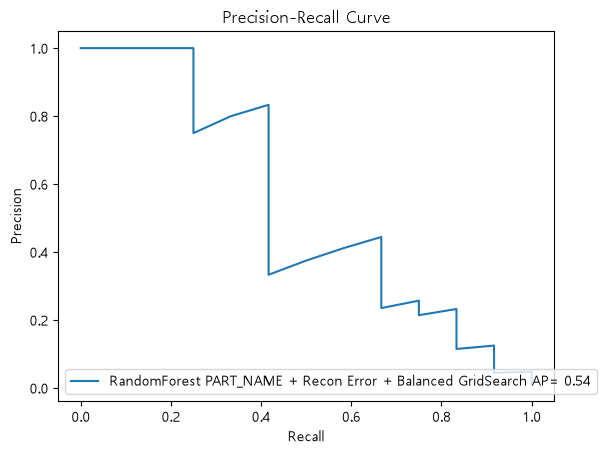

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
18,RandomForest PART_NAME+SMOTE St=0.1+Feature,0.571429,0.333333,0.421053,0.432566
19,RandomForest PART_NAME + Balanced (04_2),0.296296,0.666667,0.410256,0.569480
20,RandomForest PART_NAME + SMOTE St=0.1 (04_2),0.777778,0.583333,0.666667,0.644045
21,Bagging PART_NAME + SMOTE St=0.1 (04_2),0.538462,0.583333,0.560000,0.629020
22,RandomForest PART_NAME + Recon Error + Balance...,0.320000,0.666667,0.432432,0.543969


In [17]:
# Pipeline에 스케일링이 포함되어 있으므로 원본 x_ae_test를 사용
rf_balanced_grid_model = {
    'RandomForest PART_NAME + Recon Error + Balanced GridSearch': rf_balanced_grid.best_estimator_
}
result_df = evaluate_models(
    rf_balanced_grid_model,
    x_ae_test,
    y_test,
    result_df,
)
result_df.tail()

In [18]:
rf_balanced_grid.best_params_

{'rf__max_depth': None,
 'rf__min_samples_leaf': 4,
 'rf__min_samples_split': 2,
 'rf__n_estimators': 300}

## 2. RandomForest PART_NAME + Recon Error + SMOTE St=0.1 Grid Search

- 입력은 원본 26개 특성 + Recon_Error
- StandardScaler와 SMOTE(sampling_strategy=0.1)는 각 Stratified K-Fold의 학습 폴드 안에서만 적합
- 평가 지표는 Average Precision
- 54개 조합 × 5 folds = 270 fits

In [19]:
rf_smote_param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
}

rf_smote_grid, rf_smote_cv_results = grid_search_random_forest_smote(
    x_ae_train,
    y_train,
    param_grid=rf_smote_param_grid,
    sampling_strategy=0.1,
    smote_k_neighbors=3,
    n_splits=5,
    scoring='average_precision',
    random_state=0,
    n_jobs=-1,
    verbose=1,
)

print('Best CV Average Precision:', rf_smote_grid.best_score_)
print('Best Parameters:', rf_smote_grid.best_params_)
rf_smote_cv_results.head(10)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best CV Average Precision: 0.2688362135270526
Best Parameters: {'rf__max_depth': 20, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 1000}


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
0,1,0.268836,0.064750,14.291880,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
1,2,0.268418,0.064152,14.020441,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
2,3,0.267077,0.058958,6.340499,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
3,4,0.266293,0.058395,6.665248,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
4,5,0.265867,0.059505,12.678594,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
5,6,0.265860,0.059502,15.647566,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
6,7,0.265646,0.062527,14.535536,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
7,7,0.265646,0.062527,14.873432,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
8,7,0.265646,0.062527,14.075594,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
9,7,0.265646,0.062527,11.562818,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."


RandomForest PART_NAME + Recon Error + SMOTE St=0.1 GridSearch
Accuracy: 0.9904397705544933
Average Precision: 0.638874881598271
Classification Report
              precision    recall  f1-score   support

          양품       1.00      1.00      1.00      1034
          불량       0.58      0.58      0.58        12

    accuracy                           0.99      1046
   macro avg       0.79      0.79      0.79      1046
weighted avg       0.99      0.99      0.99      1046



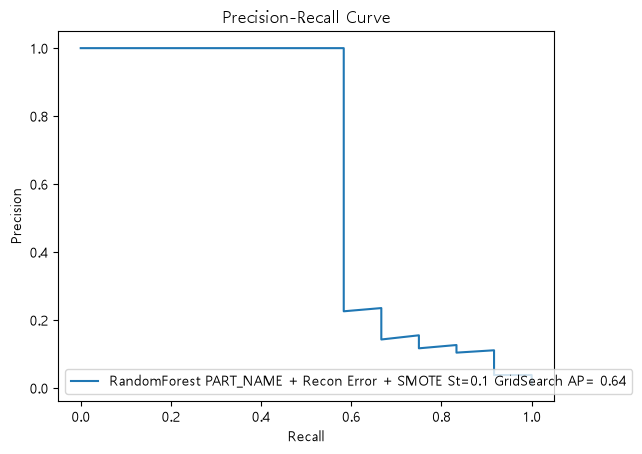

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
19,RandomForest PART_NAME + Balanced (04_2),0.296296,0.666667,0.410256,0.569480
20,RandomForest PART_NAME + SMOTE St=0.1 (04_2),0.777778,0.583333,0.666667,0.644045
21,Bagging PART_NAME + SMOTE St=0.1 (04_2),0.538462,0.583333,0.560000,0.629020
22,RandomForest PART_NAME + Recon Error + Balance...,0.320000,0.666667,0.432432,0.543969
23,RandomForest PART_NAME + Recon Error + SMOTE S...,0.583333,0.583333,0.583333,0.638875


In [20]:
# Pipeline에 스케일링과 SMOTE가 포함되어 있으므로 원본 x_ae_test를 사용
rf_smote_grid_model = {
    'RandomForest PART_NAME + Recon Error + SMOTE St=0.1 GridSearch': rf_smote_grid.best_estimator_
}
result_df = evaluate_models(
    rf_smote_grid_model,
    x_ae_test,
    y_test,
    result_df,
)
result_df.tail()

In [21]:
rf_smote_grid.best_params_

{'rf__max_depth': 20,
 'rf__min_samples_leaf': 1,
 'rf__min_samples_split': 2,
 'rf__n_estimators': 1000}

## 3. Bagging PART_NAME + Recon Error + SMOTE St=0.1 Grid Search

- 입력은 원본 26개 특성 + Recon_Error
- StandardScaler와 SMOTE(sampling_strategy=0.1)는 각 Stratified K-Fold의 학습 폴드 안에서만 적합
- 평가 지표는 Average Precision
- 27개 조합 × 5 folds = 135 fits

In [22]:
bagging_smote_param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_samples': [0.5, 0.75, 1.0],
    'max_features': [0.5, 0.75, 1.0],
}

bagging_smote_grid, bagging_smote_cv_results = grid_search_bagging_smote(
    x_ae_train,
    y_train,
    param_grid=bagging_smote_param_grid,
    sampling_strategy=0.1,
    smote_k_neighbors=3,
    n_splits=5,
    scoring='average_precision',
    random_state=0,
    n_jobs=-1,
    verbose=1,
)

print('Best CV Average Precision:', bagging_smote_grid.best_score_)
print('Best Parameters:', bagging_smote_grid.best_params_)
bagging_smote_cv_results.head(10)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


Best CV Average Precision: 0.2778270847242081
Best Parameters: {'bagging__max_features': 1.0, 'bagging__max_samples': 0.5, 'bagging__n_estimators': 300}


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
0,1,0.277827,0.075373,11.563173,"{'bagging__max_features': 1.0, 'bagging__max_s..."
1,2,0.268949,0.081135,26.026310,"{'bagging__max_features': 1.0, 'bagging__max_s..."
2,3,0.268802,0.072107,36.290118,"{'bagging__max_features': 1.0, 'bagging__max_s..."
3,4,0.268362,0.072997,20.803525,"{'bagging__max_features': 1.0, 'bagging__max_s..."
4,5,0.267827,0.072967,9.393476,"{'bagging__max_features': 0.5, 'bagging__max_s..."
5,6,0.266884,0.076934,35.930926,"{'bagging__max_features': 1.0, 'bagging__max_s..."
6,7,0.265984,0.081444,30.353143,"{'bagging__max_features': 1.0, 'bagging__max_s..."
7,8,0.265231,0.083252,15.836250,"{'bagging__max_features': 1.0, 'bagging__max_s..."
8,9,0.265071,0.071394,13.498510,"{'bagging__max_features': 1.0, 'bagging__max_s..."
9,10,0.264416,0.078987,22.010509,"{'bagging__max_features': 1.0, 'bagging__max_s..."


Bagging PART_NAME + Recon Error + SMOTE St=0.1 GridSearch
Accuracy: 0.9904397705544933
Average Precision: 0.5839903466258346
Classification Report


              precision    recall  f1-score   support

          양품       1.00      1.00      1.00      1034
          불량       0.58      0.58      0.58        12

    accuracy                           0.99      1046
   macro avg       0.79      0.79      0.79      1046
weighted avg       0.99      0.99      0.99      1046



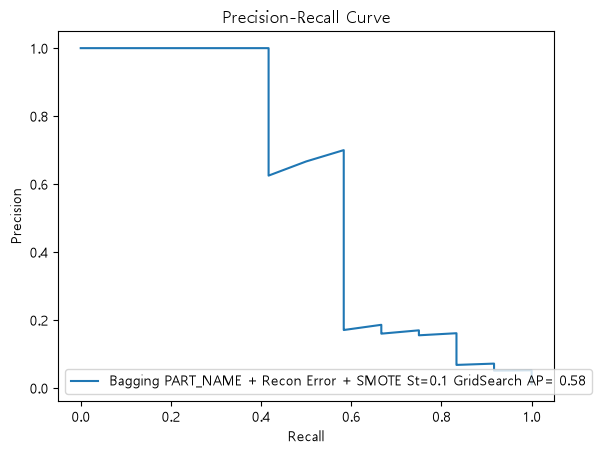

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
20,RandomForest PART_NAME + SMOTE St=0.1 (04_2),0.777778,0.583333,0.666667,0.644045
21,Bagging PART_NAME + SMOTE St=0.1 (04_2),0.538462,0.583333,0.560000,0.629020
22,RandomForest PART_NAME + Recon Error + Balance...,0.320000,0.666667,0.432432,0.543969
23,RandomForest PART_NAME + Recon Error + SMOTE S...,0.583333,0.583333,0.583333,0.638875
24,Bagging PART_NAME + Recon Error + SMOTE St=0.1...,0.583333,0.583333,0.583333,0.583990


In [23]:
# Pipeline에 스케일링과 SMOTE가 포함되어 있으므로 원본 x_ae_test를 사용
bagging_smote_grid_model = {
    'Bagging PART_NAME + Recon Error + SMOTE St=0.1 GridSearch': bagging_smote_grid.best_estimator_
}
result_df = evaluate_models(
    bagging_smote_grid_model,
    x_ae_test,
    y_test,
    result_df,
)
result_df.tail()

In [24]:
bagging_smote_grid.best_params_

{'bagging__max_features': 1.0,
 'bagging__max_samples': 0.5,
 'bagging__n_estimators': 300}

## Grid Search 결과 비교

In [25]:
compare_model_names = [
    'RandomForest PART_NAME + Balanced (04_2)',
    'RandomForest PART_NAME + SMOTE St=0.1 (04_2)',
    'Bagging PART_NAME + SMOTE St=0.1 (04_2)',
    'RandomForest PART_NAME + Recon Error + Balanced GridSearch',
    'RandomForest PART_NAME + Recon Error + SMOTE St=0.1 GridSearch',
    'Bagging PART_NAME + Recon Error + SMOTE St=0.1 GridSearch',
]

result_df[result_df['Model'].isin(compare_model_names)].sort_values(
    ['Average Precision', 'Defect Recall', 'Defect F1 Score'],
    ascending=False,
)

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
20,RandomForest PART_NAME + SMOTE St=0.1 (04_2),0.777778,0.583333,0.666667,0.644045
23,RandomForest PART_NAME + Recon Error + SMOTE S...,0.583333,0.583333,0.583333,0.638875
21,Bagging PART_NAME + SMOTE St=0.1 (04_2),0.538462,0.583333,0.560000,0.629020
24,Bagging PART_NAME + Recon Error + SMOTE St=0.1...,0.583333,0.583333,0.583333,0.583990
19,RandomForest PART_NAME + Balanced (04_2),0.296296,0.666667,0.410256,0.569480
22,RandomForest PART_NAME + Recon Error + Balance...,0.320000,0.666667,0.432432,0.543969


In [26]:
# 원본 특성 대비 Recon Error 추가 효과
metrics=['Average Precision', 'Defect Precision', 'Defect Recall', 'Defect F1 Score']
model_pairs={
    'RandomForest Balanced': ('RandomForest PART_NAME + Balanced (04_2)',
                              'RandomForest PART_NAME + Recon Error + Balanced GridSearch'),
    'RandomForest SMOTE St=0.1': ('RandomForest PART_NAME + SMOTE St=0.1 (04_2)',
                                  'RandomForest PART_NAME + Recon Error + SMOTE St=0.1 GridSearch'),
    'Bagging SMOTE St=0.1': ('Bagging PART_NAME + SMOTE St=0.1 (04_2)',
                             'Bagging PART_NAME + Recon Error + SMOTE St=0.1 GridSearch'),
}

score_df=result_df.drop_duplicates('Model', keep='last').set_index('Model')

delta_rows=[]
for model_name, (base_name, ae_name) in model_pairs.items():
    row={'Model': model_name}
    for metric in metrics:
        row[f'{metric} (원본)']=score_df.loc[base_name, metric]
        row[f'{metric} (AE)']=score_df.loc[ae_name, metric]
        row[f'{metric} 변화']=score_df.loc[ae_name, metric]-score_df.loc[base_name, metric]
    delta_rows.append(row)

pd.DataFrame(delta_rows).set_index('Model')

,Average Precision (원본),Average Precision (AE),Average Precision 변화,Defect Precision (원본),Defect Precision (AE),Defect Precision 변화,Defect Recall (원본),Defect Recall (AE),Defect Recall 변화,Defect F1 Score (원본),Defect F1 Score (AE),Defect F1 Score 변화
Model,,,,,,,,,,,,
RandomForest Balanced,0.569480,0.543969,-0.025511,0.296296,0.320000,0.023704,0.666667,0.666667,0.0,0.410256,0.432432,0.022176
RandomForest SMOTE St=0.1,0.644045,0.638875,-0.005170,0.777778,0.583333,-0.194444,0.583333,0.583333,0.0,0.666667,0.583333,-0.083333
Bagging SMOTE St=0.1,0.629020,0.583990,-0.045030,0.538462,0.583333,0.044872,0.583333,0.583333,0.0,0.560000,0.583333,0.023333


## Recon_Error 특성 중요도

In [27]:
importance_rows=[]
for name, grid in {'RandomForest + Recon Error + Balanced': rf_balanced_grid,
                   'RandomForest + Recon Error + SMOTE St=0.1': rf_smote_grid}.items():
    importance=pd.Series(grid.best_estimator_.named_steps['rf'].feature_importances_,
                         index=x_ae_train.columns).sort_values(ascending=False)
    importance_rows.append({
        'Model': name,
        'Recon_Error Importance': importance['Recon_Error'],
        'Recon_Error Rank': f"{list(importance.index).index('Recon_Error') + 1}/{len(importance)}",
        'Top Feature': importance.index[0],
    })

pd.DataFrame(importance_rows)

,Model,Recon_Error Importance,Recon_Error Rank,Top Feature
0,RandomForest + Recon Error + Balanced,0.106453,1/27,Recon_Error
1,RandomForest + Recon Error + SMOTE St=0.1,0.076349,1/27,Recon_Error


## Threshold 별 결과 확인

In [28]:
# GridSearchCV(refit=True)이므로 best_estimator_는 x_ae_train 전체로 이미 학습된 상태
best_models = {
    'RandomForest PART_NAME + Recon Error + Balanced': rf_balanced_grid.best_estimator_,
    'RandomForest PART_NAME + Recon Error + SMOTE St=0.1': rf_smote_grid.best_estimator_,
    'Bagging PART_NAME + Recon Error + SMOTE St=0.1': bagging_smote_grid.best_estimator_,
}

proba_dict = {
    name: model.predict_proba(x_ae_test)[:, 1]
    for name, model in best_models.items()
}

In [29]:
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

threshold_rows = []
for name, proba in proba_dict.items():
    print(f'[{name}]')
    for threshold in thresholds:
        pred = (proba >= threshold).astype(int)

        precision = precision_score(y_test, pred, zero_division=0)
        recall = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        # labels=[0, 1] -> 0: 양품, 1: 불량
        tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()

        threshold_rows.append({
            'Model': name,
            'Threshold': threshold,
            'Defect Precision': precision,
            'Defect Recall': recall,
            'Defect F1 Score': f1,
            '불량 탐지 수': f'{tp}/{tp + fn}',
            '양품 오탐 수': f'{fp}/{fp + tn}',
        })

        print(
            f"Threshold: {threshold:.1f} | "
            f"Precision: {precision:.3f} | "
            f"Recall: {recall:.3f} | "
            f"F1: {f1:.3f} | "
            f"불량 탐지 수: {tp}/{tp + fn} | "
            f"양품 오탐 수: {fp}/{fp + tn}"
        )
    print()

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

[RandomForest PART_NAME + Recon Error + Balanced]
Threshold: 0.5 | Precision: 0.320 | Recall: 0.667 | F1: 0.432 | 불량 탐지 수: 8/12 | 양품 오탐 수: 17/1034
Threshold: 0.4 | Precision: 0.227 | Recall: 0.833 | F1: 0.357 | 불량 탐지 수: 10/12 | 양품 오탐 수: 34/1034
Threshold: 0.3 | Precision: 0.143 | Recall: 0.833 | F1: 0.244 | 불량 탐지 수: 10/12 | 양품 오탐 수: 60/1034
Threshold: 0.2 | Precision: 0.109 | Recall: 0.917 | F1: 0.195 | 불량 탐지 수: 11/12 | 양품 오탐 수: 90/1034
Threshold: 0.1 | Precision: 0.073 | Recall: 0.917 | F1: 0.135 | 불량 탐지 수: 11/12 | 양품 오탐 수: 140/1034

[RandomForest PART_NAME + Recon Error + SMOTE St=0.1]
Threshold: 0.5 | Precision: 0.583 | Recall: 0.583 | F1: 0.583 | 불량 탐지 수: 7/12 | 양품 오탐 수: 5/1034
Threshold: 0.4 | Precision: 0.500 | Recall: 0.583 | F1: 0.538 | 불량 탐지 수: 7/12 | 양품 오탐 수: 7/1034
Threshold: 0.3 | Precision: 0.438 | Recall: 0.583 | F1: 0.500 | 불량 탐지 수: 7/12 | 양품 오탐 수: 9/1034
Threshold: 0.2 | Precision: 0.226 | Recall: 0.583 | F1: 0.326 | 불량 탐지 수: 7/12 | 양품 오탐 수: 24/1034
Threshold: 0.1 | Pre

,Model,Threshold,Defect Precision,Defect Recall,Defect F1 Score,불량 탐지 수,양품 오탐 수
0,RandomForest PART_NAME + Recon Error + Balanced,0.5,0.320000,0.666667,0.432432,8/12,17/1034
1,RandomForest PART_NAME + Recon Error + Balanced,0.4,0.227273,0.833333,0.357143,10/12,34/1034
2,RandomForest PART_NAME + Recon Error + Balanced,0.3,0.142857,0.833333,0.243902,10/12,60/1034
3,RandomForest PART_NAME + Recon Error + Balanced,0.2,0.108911,0.916667,0.194690,11/12,90/1034
4,RandomForest PART_NAME + Recon Error + Balanced,0.1,0.072848,0.916667,0.134969,11/12,140/1034
5,RandomForest PART_NAME + Recon Error + SMOTE S...,0.5,0.583333,0.583333,0.583333,7/12,5/1034
6,RandomForest PART_NAME + Recon Error + SMOTE S...,0.4,0.500000,0.583333,0.538462,7/12,7/1034
7,RandomForest PART_NAME + Recon Error + SMOTE S...,0.3,0.437500,0.583333,0.500000,7/12,9/1034
8,RandomForest PART_NAME + Recon Error + SMOTE S...,0.2,0.225806,0.583333,0.325581,7/12,24/1034
9,RandomForest PART_NAME + Recon Error + SMOTE S...,0.1,0.118421,0.750000,0.204545,9/12,67/1034


## 결과 저장

In [30]:
result_df.to_csv('04_5_AutoEncoder_GridSearch.csv', index=False)
result_df.sort_values(['Average Precision', 'Defect Recall', 'Defect F1 Score'], ascending=False).head(10)

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
13,RandomForest PART_NAME+SMOTE St=0.1,0.583333,0.583333,0.583333,0.644588
20,RandomForest PART_NAME + SMOTE St=0.1 (04_2),0.777778,0.583333,0.666667,0.644045
23,RandomForest PART_NAME + Recon Error + SMOTE S...,0.583333,0.583333,0.583333,0.638875
21,Bagging PART_NAME + SMOTE St=0.1 (04_2),0.538462,0.583333,0.560000,0.629020
14,Bagging PART_NAME+SMOTE St=0.1,0.500000,0.583333,0.538462,0.626052
12,RandomForest PART_NAME + Balanced,0.500000,0.666667,0.571429,0.596913
24,Bagging PART_NAME + Recon Error + SMOTE St=0.1...,0.583333,0.583333,0.583333,0.583990
19,RandomForest PART_NAME + Balanced (04_2),0.296296,0.666667,0.410256,0.569480
17,RandomForest PART_NAME+SMOTE St=0.1+Balanced,0.368421,0.583333,0.451613,0.553010
22,RandomForest PART_NAME + Recon Error + Balance...,0.320000,0.666667,0.432432,0.543969


## 모델 저장

In [31]:
import joblib

MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

# 오토인코더와 스케일러는 추론 시 Recon_Error 계산에 필요
for seed, ae in zip(ae_seeds, ae_list):
    ae_path=MODEL_DIR / f'ae_recon_error_seed{seed}.keras'
    ae.save(ae_path)
    print(f'오토인코더 seed {seed} -> {ae_path}')

joblib.dump(ae_scaler, MODEL_DIR / 'ae_scaler.pkl')

model_file_names = {
    'RandomForest PART_NAME + Recon Error + Balanced': 'rf_part_recon_balanced_gridsearch.pkl',
    'RandomForest PART_NAME + Recon Error + SMOTE St=0.1': 'rf_part_recon_smote_st01_gridsearch.pkl',
    'Bagging PART_NAME + Recon Error + SMOTE St=0.1': 'bagging_part_recon_smote_st01_gridsearch.pkl',
}

for name, file_name in model_file_names.items():
    file_path = MODEL_DIR / file_name
    joblib.dump(best_models[name], file_path)
    size_mb = file_path.stat().st_size / 1024 ** 2
    print(f'{name}')
    print(f'  -> {file_path} ({size_mb:.1f} MB)')

# 추론 시 열 순서가 학습 때와 같아야 하므로 입력 변수 목록도 함께 저장
joblib.dump(list(x_part_train.columns), MODEL_DIR / 'ae_input_columns.pkl')
joblib.dump(list(x_ae_train.columns), MODEL_DIR / 'recon_feature_columns.pkl')

# 불러오기 예시
# ae_list = [keras.models.load_model(MODEL_DIR / f'ae_recon_error_seed{seed}.keras') for seed in [0, 1, 2]]
# ae_scaler = joblib.load(MODEL_DIR / 'ae_scaler.pkl')
# model = joblib.load(MODEL_DIR / 'rf_part_recon_smote_st01_gridsearch.pkl')
# ae_input_columns = joblib.load(MODEL_DIR / 'ae_input_columns.pkl')
# recon_feature_columns = joblib.load(MODEL_DIR / 'recon_feature_columns.pkl')
# scaled = ae_scaler.transform(new_x[ae_input_columns])
# errors = [np.mean(np.square(ae.predict(scaled, verbose=0) - scaled), axis=1) for ae in ae_list]
# new_x = new_x.assign(Recon_Error=np.mean(errors, axis=0))
# proba = model.predict_proba(new_x[recon_feature_columns])[:, 1]

오토인코더 seed 0 -> C:\Users\subin\Desktop\KMU\산학프로젝트\manufacturing-defect-prediction\models\ae_recon_error_seed0.keras


오토인코더 seed 1 -> C:\Users\subin\Desktop\KMU\산학프로젝트\manufacturing-defect-prediction\models\ae_recon_error_seed1.keras
오토인코더 seed 2 -> C:\Users\subin\Desktop\KMU\산학프로젝트\manufacturing-defect-prediction\models\ae_recon_error_seed2.keras
RandomForest PART_NAME + Recon Error + Balanced
  -> C:\Users\subin\Desktop\KMU\산학프로젝트\manufacturing-defect-prediction\models\rf_part_recon_balanced_gridsearch.pkl (2.3 MB)


RandomForest PART_NAME + Recon Error + SMOTE St=0.1
  -> C:\Users\subin\Desktop\KMU\산학프로젝트\manufacturing-defect-prediction\models\rf_part_recon_smote_st01_gridsearch.pkl (15.9 MB)
Bagging PART_NAME + Recon Error + SMOTE St=0.1
  -> C:\Users\subin\Desktop\KMU\산학프로젝트\manufacturing-defect-prediction\models\bagging_part_recon_smote_st01_gridsearch.pkl (2.5 MB)


['C:\\Users\\subin\\Desktop\\KMU\\산학프로젝트\\manufacturing-defect-prediction\\models\\recon_feature_columns.pkl']

## 실험 결과 해석

### 오토인코더

- 선택 구조: `26 → 20 → 12 → 20 → 26`, 평균 val_loss 0.000148 (시드 편차 0.000003)로 후보 중 가장 낮고 안정적
- 복원 오차 평균: 양품 0.000124 / 불량 0.005666 (중앙값은 0.000097 / 0.000499)
- 복원 오차 단독 Average Precision 0.4799 (무작위 기준선 0.0115)
- 3σ, 5σ 규칙 단독으로는 양품 오탐이 0건이지만 12건 중 4건(Recall 0.333)만 탐지하므로, 판정 규칙으로 쓰기는 어렵고 특성으로만 사용

### Grid Search (holdout, threshold 0.5)

원본 AP는 04_2에서 고른 파라미터를 같은 분할로 다시 학습한 값

| 모델 | 원본 AP | +Recon_Error AP | AP 변화 | Recall 변화 |
| --- | --- | --- | --- | --- |
| RandomForest Balanced | 0.5695 | 0.5440 | -0.0255 | 0.000 |
| RandomForest SMOTE St=0.1 | 0.6440 | 0.6389 | -0.0051 | 0.000 |
| Bagging SMOTE St=0.1 | 0.6290 | 0.5840 | -0.0450 | 0.000 |

- 불량 Recall은 세 모델 모두 원본과 같고, Bagging만 Precision이 0.538 → 0.583으로 올라 F1이 0.560 → 0.583이 됨
- GridSearch CV Average Precision은 세 모델 모두 올랐지만(Balanced 0.2954 → 0.3104, RandomForest SMOTE 0.2635 → 0.2688, Bagging 0.2522 → 0.2778), 오토인코더를 fold 밖에서 1회 학습했으므로 낙관 편향이 있어 holdout 기준으로 판단
- `Recon_Error`는 두 RandomForest 모델 모두 중요도 1위/27 (0.106, 0.076)로 실제 분할에 사용됨. 단 불순도 기반 중요도는 연속형 변수에 유리하므로 과대평가 가능

### 결론

- **복원 오차 추가로 성능이 개선되었다고 보기 어려움.** holdout AP가 세 모델 모두 떨어졌고, 변화폭 -0.005 ~ -0.045는 평가 데이터 불량이 12건이므로 불량 1건 예측이 바뀌면 뒤집히는 크기
- CV AP는 오르고 holdout AP는 내려가 방향이 엇갈림. 오토인코더를 fold 밖에서 1회 학습한 낙관 편향이 원인으로 보이며, fold 안에서 다시 학습해 확인해야 함
- 복원 오차는 초기 가중치에 따라 흔들리므로 시드 3개를 평균해 계산함. 시드 1개 기준 수치는 재현되지 않음
- 이 부분은 `04_6_AutoEncoder_CV_Validation`에서 각 CV 학습 fold 안에서 오토인코더를 다시 학습하고 5-fold × 3반복으로 검증함
  - SMOTE 계열은 AP 짝차이 중앙값 +0.006~+0.011 (개선 fold 10/15, 11/15), Balanced는 효과 없음 (8/15)
  - 같은 검증에서 `random_state=0` 분할이 유리한 분할이었음도 확인됨 (원본 AP 0.64 → CV 평균 0.35)